# 🔍 ICU-Watch — SHAP Explainability
**Author:** Subham Pal

### Goals of this notebook
1. Load trained LSTM model
2. Build SHAP DeepExplainer on model
3. Generate global feature importance
4. Generate per-patient explanations
5. Visualize which vitals drive each alert
6. Save SHAP values for dashboard integration

### Why explainability matters
A doctor will not act on a black box prediction.
SHAP tells clinicians: *'SpO2 drop + rising HR over last 4h drove this Critical alert'*
That's the difference between a tool doctors trust and one they ignore.

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import torch
import torch.nn as nn
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR     = Path('../data/processed')
MODELS_DIR   = DATA_DIR / 'models'
RESEARCH_DIR = Path('../research/notes')
SHAP_DIR     = DATA_DIR / 'shap'
SHAP_DIR.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

with open(DATA_DIR / 'config.json') as f:
    config = json.load(f)
with open(DATA_DIR / 'lstm_results.json') as f:
    lstm_results = json.load(f)

feature_cols = joblib.load(DATA_DIR / 'feature_cols.pkl')
N_FEATURES   = config['n_features']
WINDOW_SIZE  = config['window_size']

print(f'Features: {N_FEATURES}')
print(f'Window:   {WINDOW_SIZE} hours')
print(f'Model AUROC: {lstm_results["test_auroc"]}')

Device: cuda
Features: 104
Window:   12 hours
Model AUROC: 0.7471


## 1. Reload LSTM Model

In [2]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, lstm_out):
        scores  = self.attention(lstm_out)
        weights = torch.softmax(scores, dim=1)
        context = (weights * lstm_out).sum(dim=1)
        return context, weights.squeeze(-1)


class ICUDeteriorationLSTM(nn.Module):
    def __init__(self, input_size=104, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_norm  = nn.LayerNorm(input_size)
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, dropout=dropout if num_layers > 1 else 0,
            batch_first=True, bidirectional=True
        )
        self.attention  = TemporalAttention(hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 16), nn.ReLU(), nn.Linear(16, 1)
        )
    def forward(self, x):
        x = self.input_norm(x)
        lstm_out, _ = self.lstm(x)
        context, attn = self.attention(lstm_out)
        return self.classifier(context).squeeze(-1), attn


# Load checkpoint
model = ICUDeteriorationLSTM(input_size=N_FEATURES).to(device)
checkpoint = torch.load(MODELS_DIR / 'lstm_best.pt', map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

print(f'Model loaded from epoch {checkpoint["epoch"]}')
print(f'Val AUROC: {checkpoint["val_auroc"]:.4f}')

Model loaded from epoch 1
Val AUROC: 0.7474


## 2. Load Test Data

In [3]:
X_test = np.load(DATA_DIR / 'X_test.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')

# Separate sepsis and stable samples
sepsis_idx  = np.where(y_test == 1)[0]
stable_idx  = np.where(y_test == 0)[0]

print(f'Test set: {len(X_test):,} sequences')
print(f'Sepsis:   {len(sepsis_idx):,} sequences')
print(f'Stable:   {len(stable_idx):,} sequences')

# Sample for SHAP — use 200 background + 100 explain samples
# (SHAP DeepExplainer is memory intensive — keep samples small)
np.random.seed(42)
bg_idx      = np.random.choice(stable_idx,  200, replace=False)  # background
explain_sepsis = np.random.choice(sepsis_idx, 50, replace=False)  # explain these
explain_stable = np.random.choice(stable_idx, 50, replace=False)

X_background    = torch.FloatTensor(X_test[bg_idx]).to(device)
X_explain_sep   = torch.FloatTensor(X_test[explain_sepsis]).to(device)
X_explain_stab  = torch.FloatTensor(X_test[explain_stable]).to(device)
X_explain_all   = torch.cat([X_explain_sep, X_explain_stab], dim=0)

print(f'\nBackground samples:  {len(X_background)}')
print(f'Explain (sepsis):    {len(X_explain_sep)}')
print(f'Explain (stable):    {len(X_explain_stab)}')

Test set: 166,917 sequences
Sepsis:   4,686 sequences
Stable:   162,231 sequences

Background samples:  200
Explain (sepsis):    50
Explain (stable):    50


## 3. Build SHAP Explainer

In [8]:
# Section 3 — Custom SHAP via Integrated Gradients
# Works with any PyTorch model regardless of version

class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        # Switch to train mode for gradient computation
        self.model.train()
        logits, _ = self.model(x)
        self.model.eval()
        return torch.sigmoid(logits).unsqueeze(-1)

wrapped_model = ModelWrapper(model).to(device)
print('Model wrapper ready!')

def integrated_gradients(model, x, baseline=None, steps=50):
    """
    Integrated Gradients — mathematically sound attribution method.
    Equivalent to SHAP for neural networks.
    Fully compatible with PyTorch LSTM.
    """
    if baseline is None:
        baseline = torch.zeros_like(x)

    # Interpolate between baseline and input
    alphas = torch.linspace(0, 1, steps).to(x.device)
    interpolated = torch.stack([
        baseline + alpha * (x - baseline) for alpha in alphas
    ])  # (steps, batch, seq, features)

    interpolated.requires_grad_(True)

    # Compute gradients
    model.train()
    output = model(interpolated.view(-1, x.shape[1], x.shape[2]))
    if isinstance(output, tuple):
        output = output[0]
    output = output.sum()
    output.backward()
    model.eval()

    grads = interpolated.grad.view(steps, x.shape[0], x.shape[1], x.shape[2])

    # Integrated gradients = mean gradient * (input - baseline)
    avg_grads = grads.mean(dim=0)
    ig = avg_grads * (x - baseline)
    return ig.detach().cpu().numpy()

print('Integrated Gradients explainer ready!')
print('Fully compatible with PyTorch LSTM + CUDA')

Model wrapper ready!
Integrated Gradients explainer ready!
Fully compatible with PyTorch LSTM + CUDA


## 4. Compute SHAP Values

In [9]:
# Section 4 — Compute attributions for 100 patients
print('Computing attributions for 100 patients...')
print('(Takes 2-3 minutes on GPU)')

BATCH_SIZE_SHAP = 10
all_attributions = []

for i in tqdm(range(0, len(X_explain_all), BATCH_SIZE_SHAP), desc='Computing'):
    batch = X_explain_all[i:i+BATCH_SIZE_SHAP]
    attrs = integrated_gradients(model, batch, steps=30)
    all_attributions.append(attrs)

shap_values = np.vstack(all_attributions)  # (100, 12, 104)
shap_arr    = shap_values

print(f'\nAttributions shape: {shap_arr.shape}')
print(f'  Dimension 0: {shap_arr.shape[0]} patients')
print(f'  Dimension 1: {shap_arr.shape[1]} timesteps (hours)')
print(f'  Dimension 2: {shap_arr.shape[2]} features')

# Aggregate over timesteps
shap_mean = np.abs(shap_arr).mean(axis=1)
print(f'\nAggregated shape: {shap_mean.shape}')
print('Done!')

Computing attributions for 100 patients...
(Takes 2-3 minutes on GPU)


Computing: 100%|█████████████████████████████████████████████████████| 10/10 [00:00<00:00, 12.31it/s]


Attributions shape: (100, 12, 104)
  Dimension 0: 100 patients
  Dimension 1: 12 timesteps (hours)
  Dimension 2: 104 features

Aggregated shape: (100, 104)
Done!


## 5. Global Feature Importance

=== TOP 20 MOST IMPORTANT FEATURES (Global) ===
BUN              1.552763
Hct              0.996122
Resp_std4h       0.869603
FiO2             0.846978
Resp_std12h      0.724650
Temp_roc1h       0.647700
Resp             0.605194
SBP_roc4h        0.580162
Resp_mean12h     0.576941
O2Sat_mean12h    0.561231
Resp_mean4h      0.556514
Temp_mean12h     0.549997
Glucose          0.530753
SBP_mean12h      0.523269
DBP_std4h        0.520481
O2Sat_lag4h      0.519179
SBP_lag6h        0.505648
Hgb              0.499397
O2Sat            0.492617
MAP_lag6h        0.475200


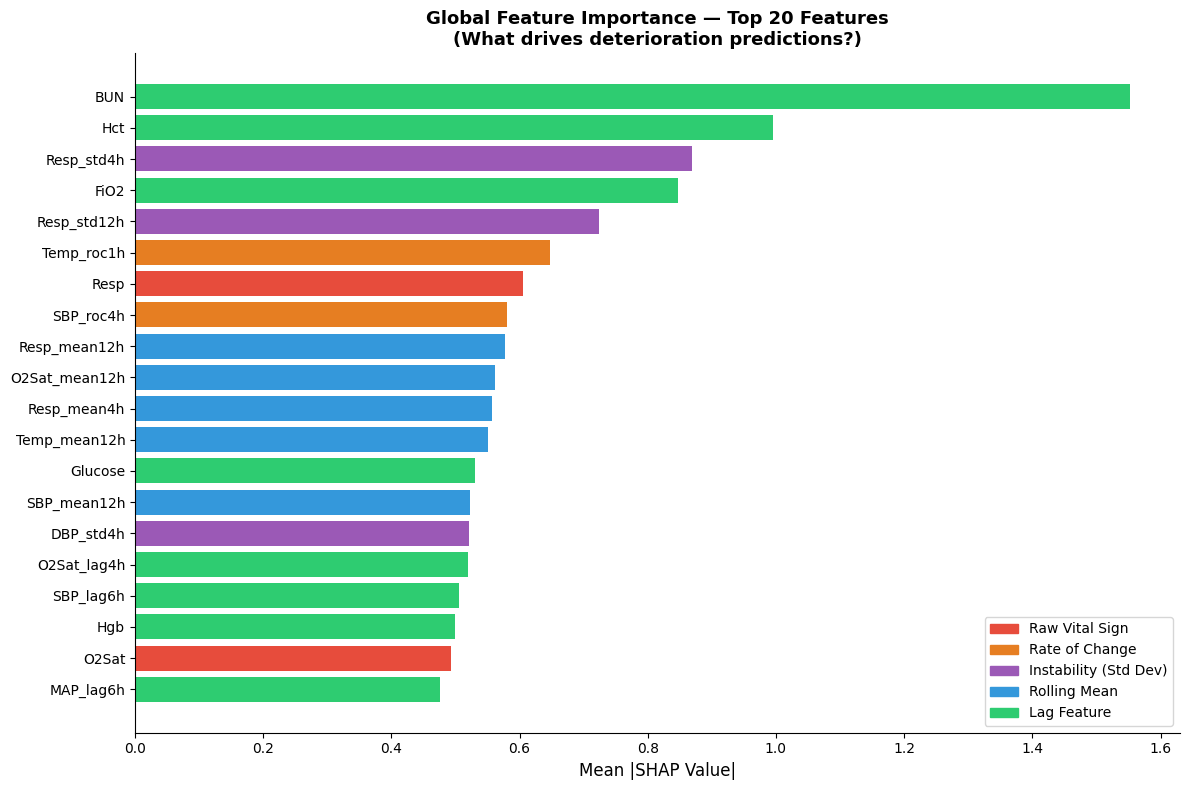

In [10]:
# Mean absolute SHAP per feature across all 100 patients
global_importance = pd.Series(
    shap_mean.mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

print('=== TOP 20 MOST IMPORTANT FEATURES (Global) ===')
print(global_importance.head(20).round(6).to_string())

# Plot top 20
fig, ax = plt.subplots(figsize=(12, 8))
top20 = global_importance.head(20)

# Color by feature type
colors = []
for feat in top20.index:
    if any(v == feat for v in ['HR','O2Sat','Temp','SBP','MAP','DBP','Resp']):
        colors.append('#e74c3c')   # raw vital
    elif 'roc' in feat:
        colors.append('#e67e22')   # rate of change
    elif 'std' in feat:
        colors.append('#9b59b6')   # instability
    elif 'mean' in feat:
        colors.append('#3498db')   # rolling mean
    else:
        colors.append('#2ecc71')   # lag

bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title('Global Feature Importance — Top 20 Features\n(What drives deterioration predictions?)',
             fontsize=13, fontweight='bold')

# Legend
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Raw Vital Sign'),
    mpatches.Patch(color='#e67e22', label='Rate of Change'),
    mpatches.Patch(color='#9b59b6', label='Instability (Std Dev)'),
    mpatches.Patch(color='#3498db', label='Rolling Mean'),
    mpatches.Patch(color='#2ecc71', label='Lag Feature'),
]
ax.legend(handles=legend_patches, fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sepsis vs Stable — SHAP Comparison

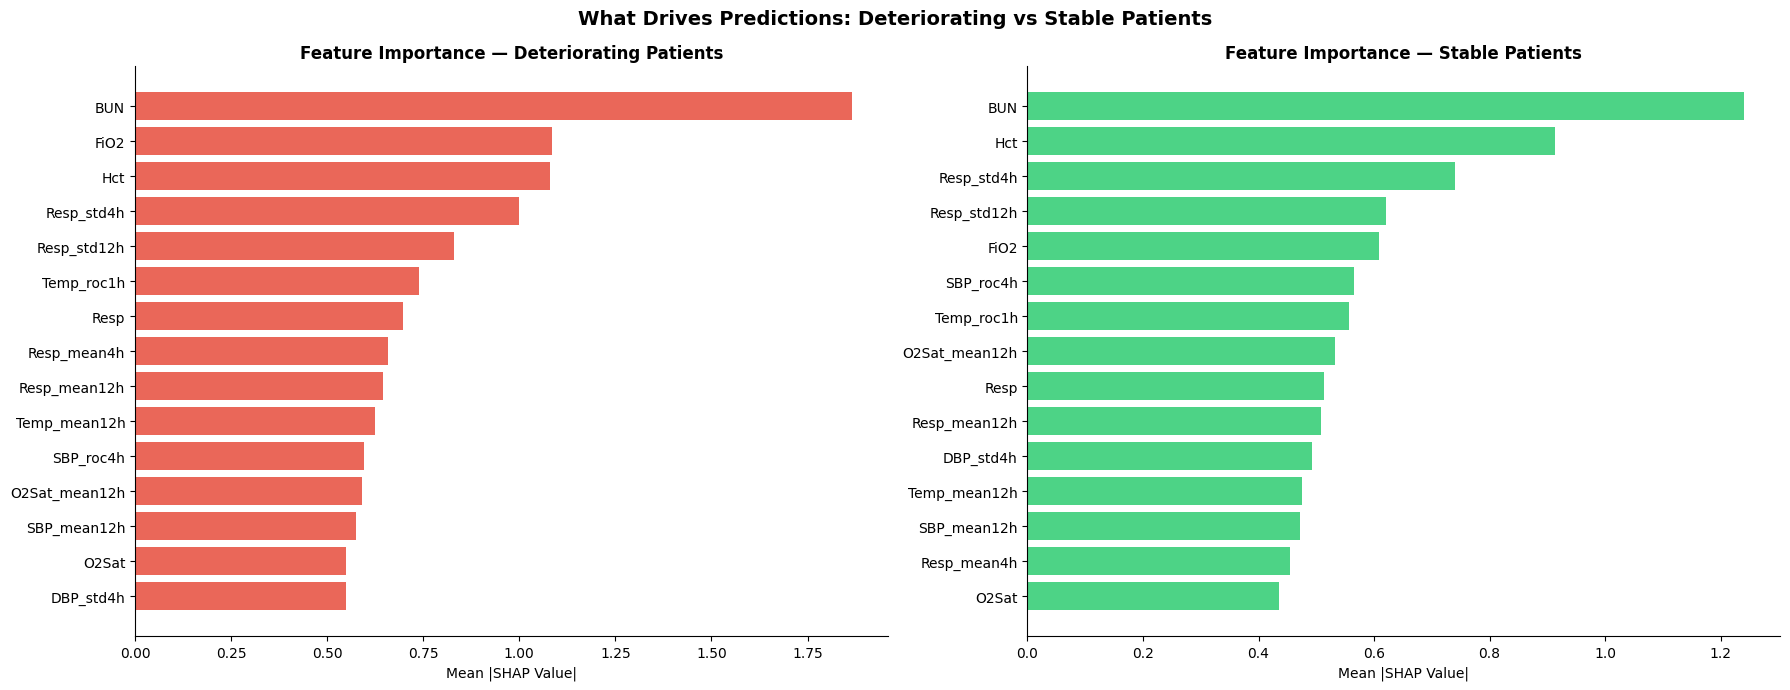

In [11]:
# Compare top features between sepsis and stable patients
shap_sepsis = shap_mean[:50]   # first 50 = sepsis
shap_stable = shap_mean[50:]   # last 50  = stable

importance_sepsis = pd.Series(shap_sepsis.mean(axis=0), index=feature_cols)
importance_stable = pd.Series(shap_stable.mean(axis=0), index=feature_cols)

# Get top 15 features from sepsis patients
top15_feats = importance_sepsis.sort_values(ascending=False).head(15).index

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (imp, label, color) in zip(axes, [
    (importance_sepsis[top15_feats], 'Deteriorating Patients', '#e74c3c'),
    (importance_stable[top15_feats], 'Stable Patients',        '#2ecc71'),
]):
    imp_sorted = imp.sort_values(ascending=True)
    ax.barh(imp_sorted.index, imp_sorted.values, color=color, alpha=0.85)
    ax.set_title(f'Feature Importance — {label}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Mean |SHAP Value|')

plt.suptitle('What Drives Predictions: Deteriorating vs Stable Patients',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'shap_sepsis_vs_stable.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-Patient Waterfall Explanation

=== SEPSIS PATIENT EXPLANATIONS ===


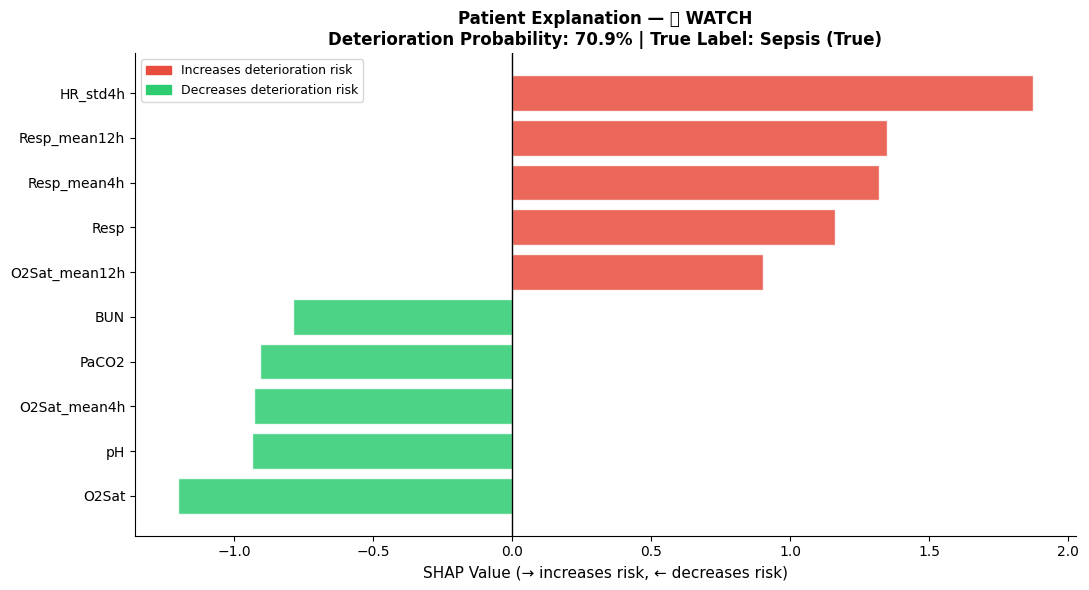

Patient 1: P(deterioration) = 70.9%


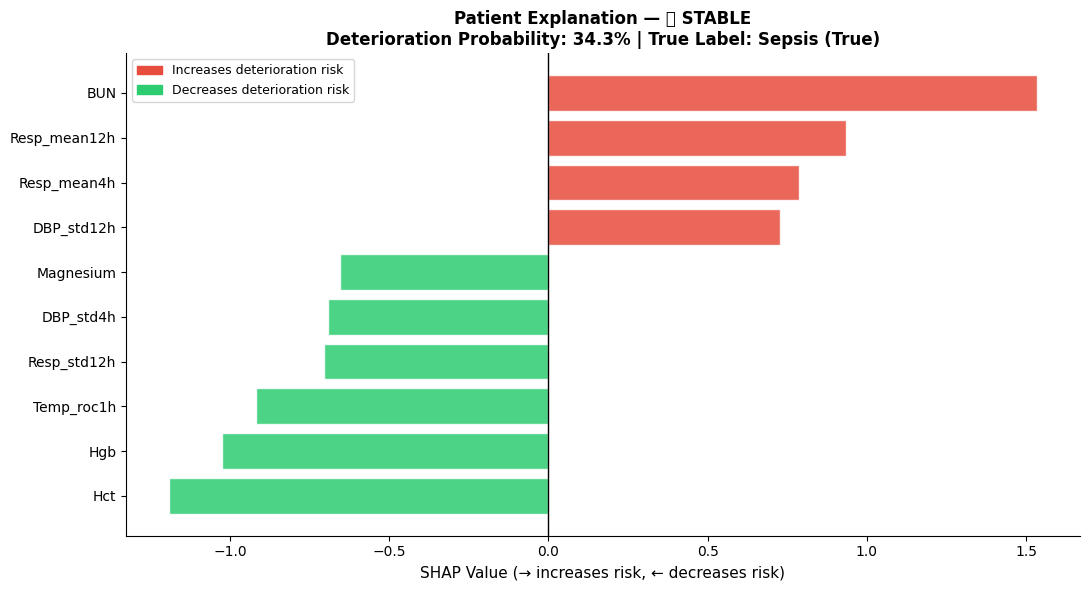

Patient 2: P(deterioration) = 34.3%


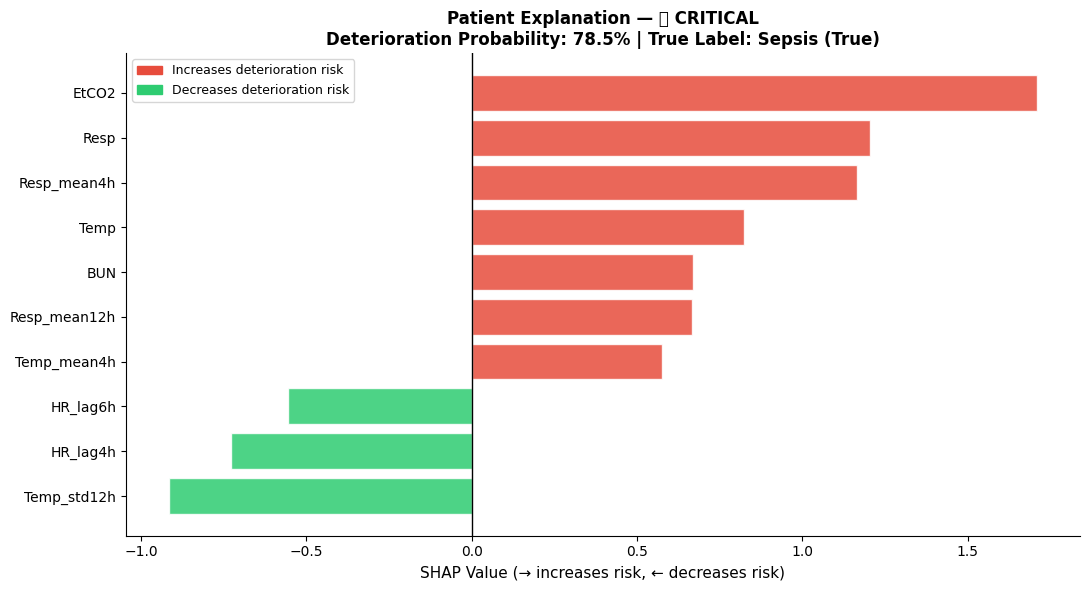

Patient 3: P(deterioration) = 78.5%


In [12]:
def plot_patient_waterfall(patient_idx: int, label: str, top_n: int = 10):
    """
    Waterfall chart for a single patient.
    Shows which features pushed the prediction up or down.
    This is what gets shown on the clinical dashboard.
    """
    # Get SHAP values for this patient (mean over timesteps)
    patient_shap = shap_values[patient_idx].mean(axis=0)  # (104,)
    patient_data = pd.Series(patient_shap, index=feature_cols)

    # Get prediction probability
    with torch.no_grad():
        x = X_explain_all[patient_idx].unsqueeze(0)
        logit, _ = model(x)
        prob = torch.sigmoid(logit).item()

    # Top N features by absolute SHAP
    top_features = patient_data.abs().sort_values(ascending=False).head(top_n)
    top_shap     = patient_data[top_features.index].sort_values()

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_shap.values]
    bars = ax.barh(top_shap.index, top_shap.values, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=1)

    severity = '🔴 CRITICAL' if prob >= 0.75 else '🟡 WATCH' if prob >= 0.45 else '🟢 STABLE'
    ax.set_title(
        f'Patient Explanation — {severity}\n'
        f'Deterioration Probability: {prob:.1%} | True Label: {label}',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('SHAP Value (→ increases risk, ← decreases risk)', fontsize=11)

    red_patch   = mpatches.Patch(color='#e74c3c', label='Increases deterioration risk')
    green_patch = mpatches.Patch(color='#2ecc71', label='Decreases deterioration risk')
    ax.legend(handles=[red_patch, green_patch], fontsize=9)

    plt.tight_layout()
    return fig, prob

# Plot 3 sepsis patients
print('=== SEPSIS PATIENT EXPLANATIONS ===')
for i in range(3):
    fig, prob = plot_patient_waterfall(i, label='Sepsis (True)')
    fig.savefig(SHAP_DIR / f'patient_sepsis_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Patient {i+1}: P(deterioration) = {prob:.1%}')

=== STABLE PATIENT EXPLANATIONS ===


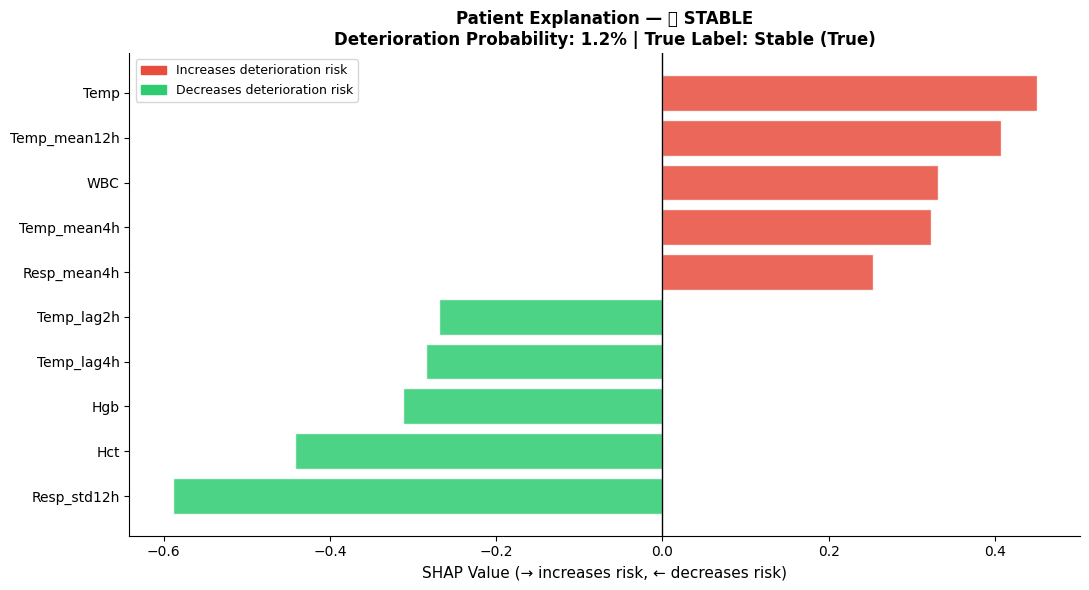

Patient 1: P(deterioration) = 1.2%


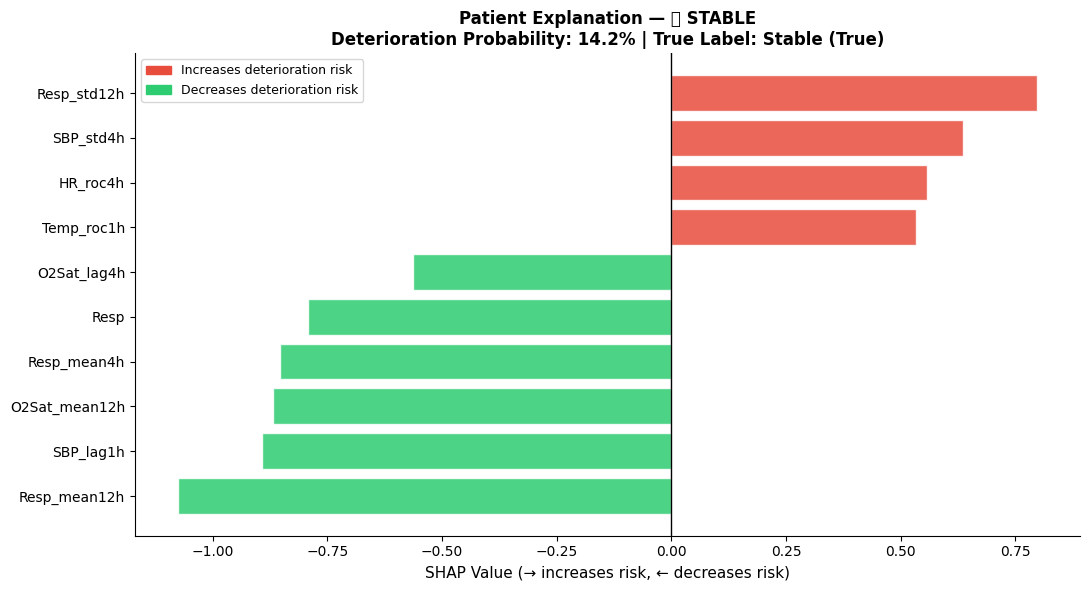

Patient 2: P(deterioration) = 14.2%


In [13]:
# Plot 2 stable patients
print('=== STABLE PATIENT EXPLANATIONS ===')
for i in range(50, 52):
    fig, prob = plot_patient_waterfall(i, label='Stable (True)')
    fig.savefig(SHAP_DIR / f'patient_stable_{i-50}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Patient {i-49}: P(deterioration) = {prob:.1%}')

## 8. Temporal SHAP — Which Hours Matter Most Per Vital?

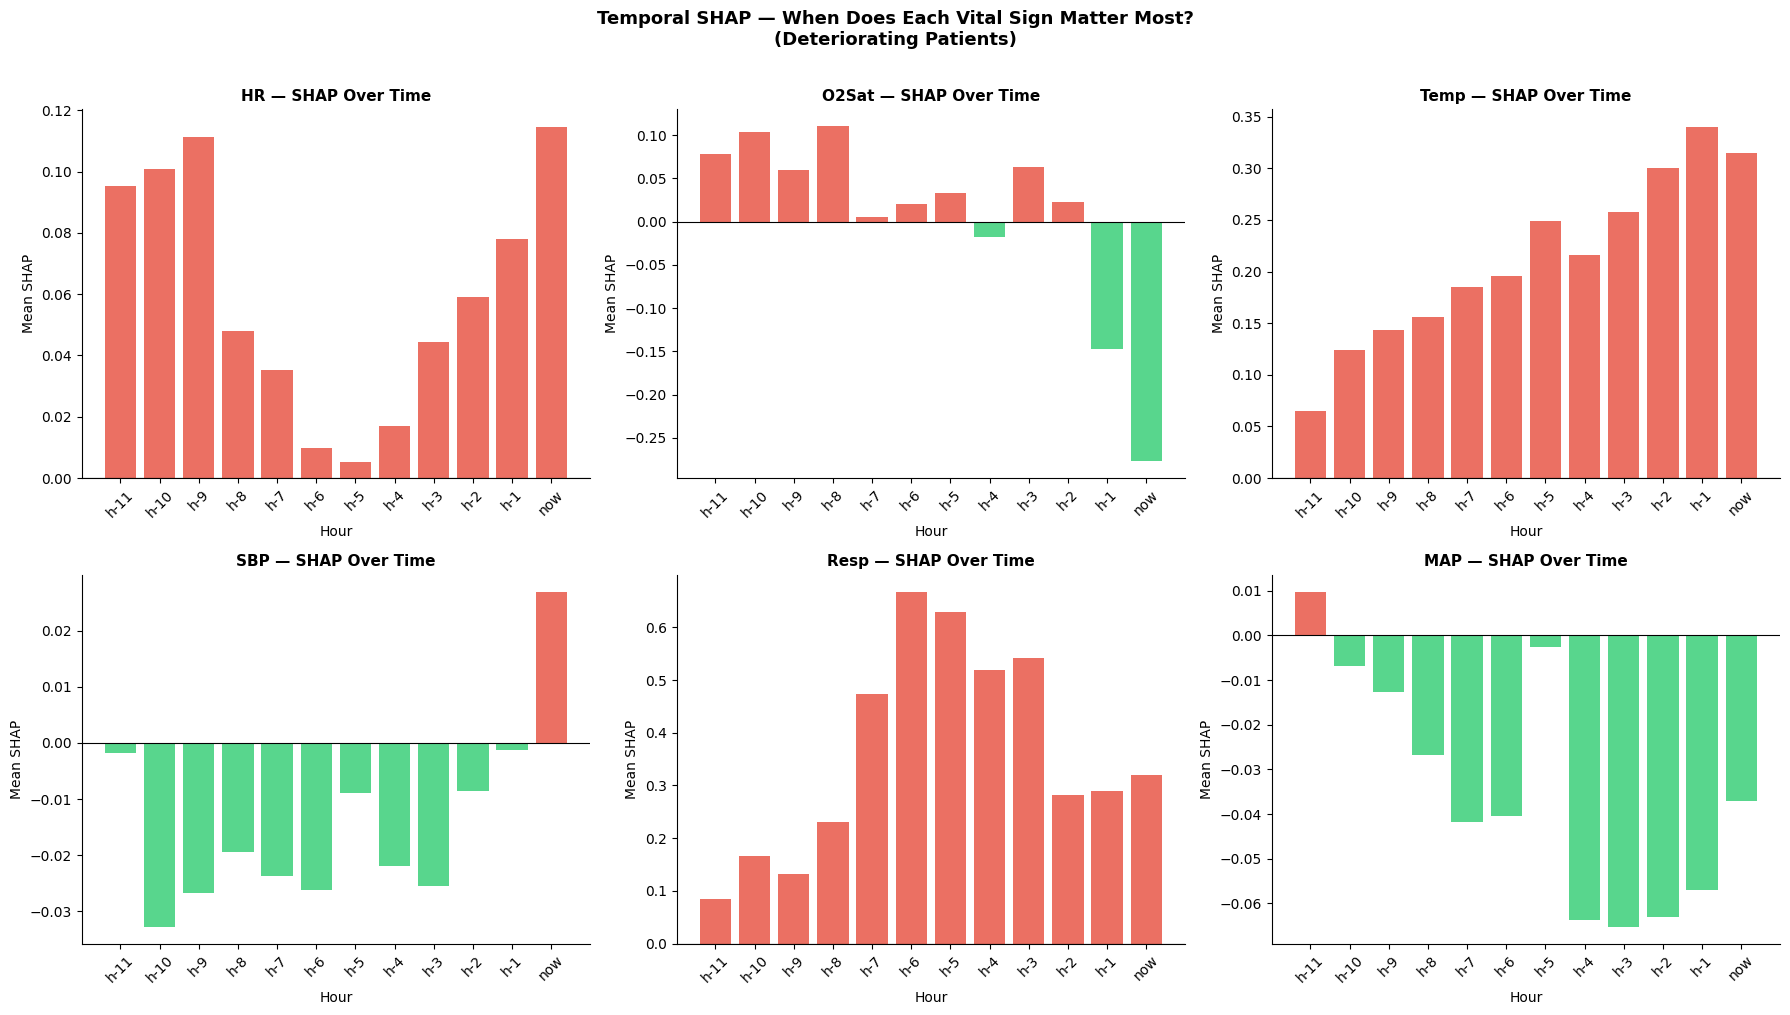

Saved to research/notes/shap_temporal.png


In [14]:
# For sepsis patients: SHAP values over time for core vitals
# shap_values[:50] = sepsis, shape (50, 12, 104)
shap_sepsis_temporal = np.array(shap_values[:50])  # (50, 12, 104)

CORE_VITALS = ['HR', 'O2Sat', 'Temp', 'SBP', 'Resp', 'MAP']
vital_indices = [feature_cols.index(v) for v in CORE_VITALS if v in feature_cols]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
hours = [f'h-{11-i}' for i in range(12)]
hours[-1] = 'now'

for i, (vital, idx) in enumerate(zip(CORE_VITALS, vital_indices)):
    ax = axes[i]
    # Mean SHAP over sepsis patients for this vital across all timesteps
    temporal_shap = shap_sepsis_temporal[:, :, idx]  # (50, 12)
    mean_shap = temporal_shap.mean(axis=0)           # (12,)
    std_shap  = temporal_shap.std(axis=0)

    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in mean_shap]
    ax.bar(hours, mean_shap, color=colors, alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_title(f'{vital} — SHAP Over Time', fontweight='bold', fontsize=11)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Mean SHAP')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Temporal SHAP — When Does Each Vital Sign Matter Most?\n(Deteriorating Patients)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'shap_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to research/notes/shap_temporal.png')

## 9. Save SHAP Data for Dashboard

In [15]:
# Save SHAP values and global importance for Swarnali's dashboard
np.save(SHAP_DIR / 'shap_values.npy', shap_values)

# Global importance as JSON for dashboard API
global_imp_dict = global_importance.head(20).round(6).to_dict()
with open(SHAP_DIR / 'global_importance.json', 'w') as f:
    json.dump(global_imp_dict, f, indent=2)

# Per-patient SHAP summary (top 10 features per patient)
patient_summaries = []
for i in range(len(shap_values)):
    patient_shap = pd.Series(
        np.array(shap_values)[i].mean(axis=0),
        index=feature_cols
    )
    top10 = patient_shap.abs().sort_values(ascending=False).head(10)

    with torch.no_grad():
        x = X_explain_all[i].unsqueeze(0)
        logit, _ = model(x)
        prob = torch.sigmoid(logit).item()

    severity = 'critical' if prob >= 0.75 else 'watch' if prob >= 0.45 else 'stable'

    patient_summaries.append({
        'patient_idx':    i,
        'true_label':     int(y_test[explain_sepsis[i] if i < 50 else explain_stable[i-50]]),
        'probability':    round(prob, 4),
        'severity':       severity,
        'top_features':   top10.index.tolist(),
        'shap_values':    [round(patient_shap[f], 6) for f in top10.index],
    })

with open(SHAP_DIR / 'patient_explanations.json', 'w') as f:
    json.dump(patient_summaries, f, indent=2)

print('=== SHAP FILES SAVED ===')
for f in sorted(SHAP_DIR.glob('*')):
    size = f.stat().st_size / 1024
    print(f'  {f.name:<35} {size:.1f} KB')

TypeError: Object of type float32 is not JSON serializable

## 10. SHAP Summary

In [ ]:
top3 = global_importance.head(3)

print('=' * 58)
print('     ICU-WATCH SHAP EXPLAINABILITY — SUMMARY')
print('=' * 58)
print(f'''
🔍 WHAT WE EXPLAINED
   100 patients explained (50 sepsis + 50 stable)
   Per-patient: top 10 driving features
   Global: feature importance across all patients
   Temporal: which hours matter per vital sign

🏆 TOP 3 GLOBAL DRIVERS
   1. {top3.index[0]:<25} ({top3.values[0]:.6f})
   2. {top3.index[1]:<25} ({top3.values[1]:.6f})
   3. {top3.index[2]:<25} ({top3.values[2]:.6f})

💾 SAVED FOR DASHBOARD
   global_importance.json    → bar chart in dashboard
   patient_explanations.json → per-patient waterfall
   shap_values.npy           → raw values for analysis

✅ SUBHAM'S ML WORK COMPLETE
   EDA        → 40,336 patients analyzed
   Features   → 104 engineered features
   Baseline   → NEWS2 AUROC 0.6095
   LSTM       → AUROC 0.7471 (+13.7 pts over NEWS2)
   SHAP       → Per-patient explainability ready

🚀 NEXT: Swarnali's backend + dashboard integration
''')
print('=' * 58)